In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_auc_score,roc_curve,precision_score,recall_score,f1_score
from sklearn.linear_model import LogisticRegression
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data read

In [3]:
file_id = '1wxN49svKOrCcHqWp99njFxwaYC0fvs1Q'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
df = pd.read_csv(url)

df.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0.0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0.0


Data info

In [4]:
df.shape

(19158, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  float64
dtypes: float64(2), int64(2), object(10)
me

In [6]:
df.describe()

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000


In [7]:
print("\nMissing Values:")
df.isnull().sum()


Missing Values:


,0
enrollee_id,0
city,0
city_development_index,0
gender,4508
relevent_experience,0
enrolled_university,386
education_level,460
major_discipline,2813
experience,65
company_size,5938


In [8]:
print("\nNumber of Duplicates:")
df.duplicated().sum()



Number of Duplicates:


np.int64(0)

In [9]:
df['target'].value_counts()
print(df['target'].value_counts())
print((df['target'].value_counts(normalize=True)*100).round(1))

target
0.0    14381
1.0     4777
Name: count, dtype: int64
target
0.0    75.1
1.0    24.9
Name: proportion, dtype: float64


#Visualization

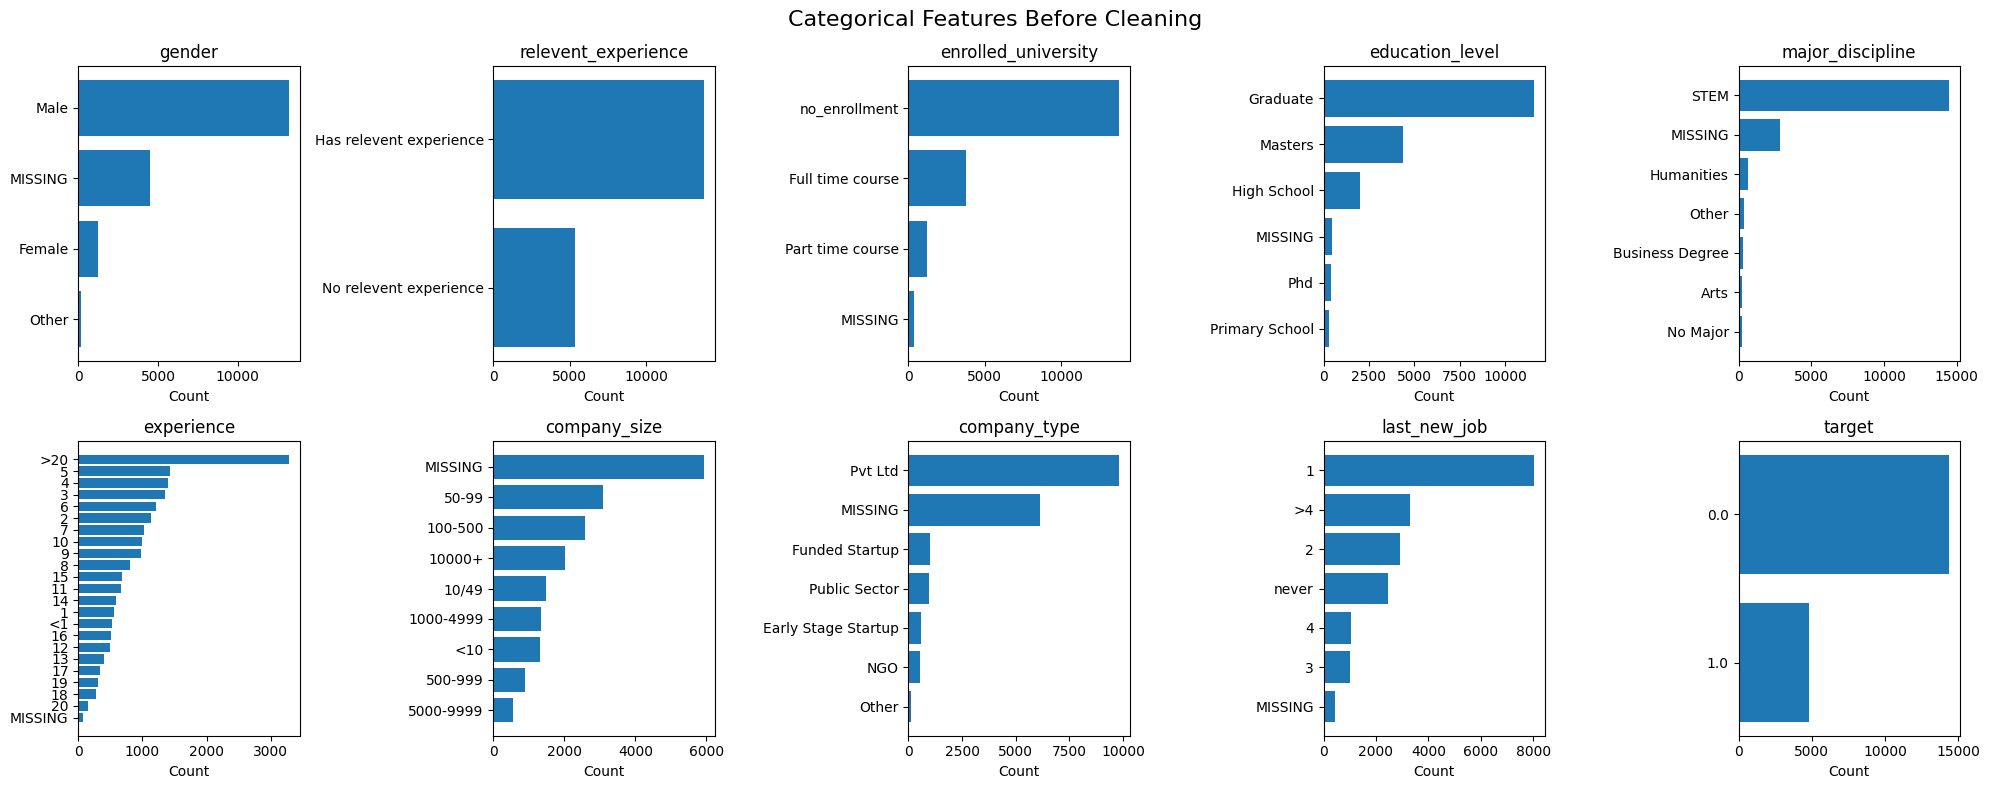

In [10]:
cat_cols = [
    "gender",
    "relevent_experience",
    "enrolled_university",
    "education_level",
    "major_discipline",
    "experience",
    "company_size",
    "company_type",
    "last_new_job",
    "target"
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, col in zip(axes.ravel(), cat_cols):

    counts = df[col].value_counts(dropna=False)

    labels = [
        "MISSING" if pd.isna(x) else str(x)
        for x in counts.index
    ]

    ax.barh(labels[::-1], counts.values[::-1])

    ax.set_title(col)
    ax.set_xlabel("Count")

plt.suptitle("Categorical Features Before Cleaning", fontsize=16)

plt.tight_layout()
plt.show()

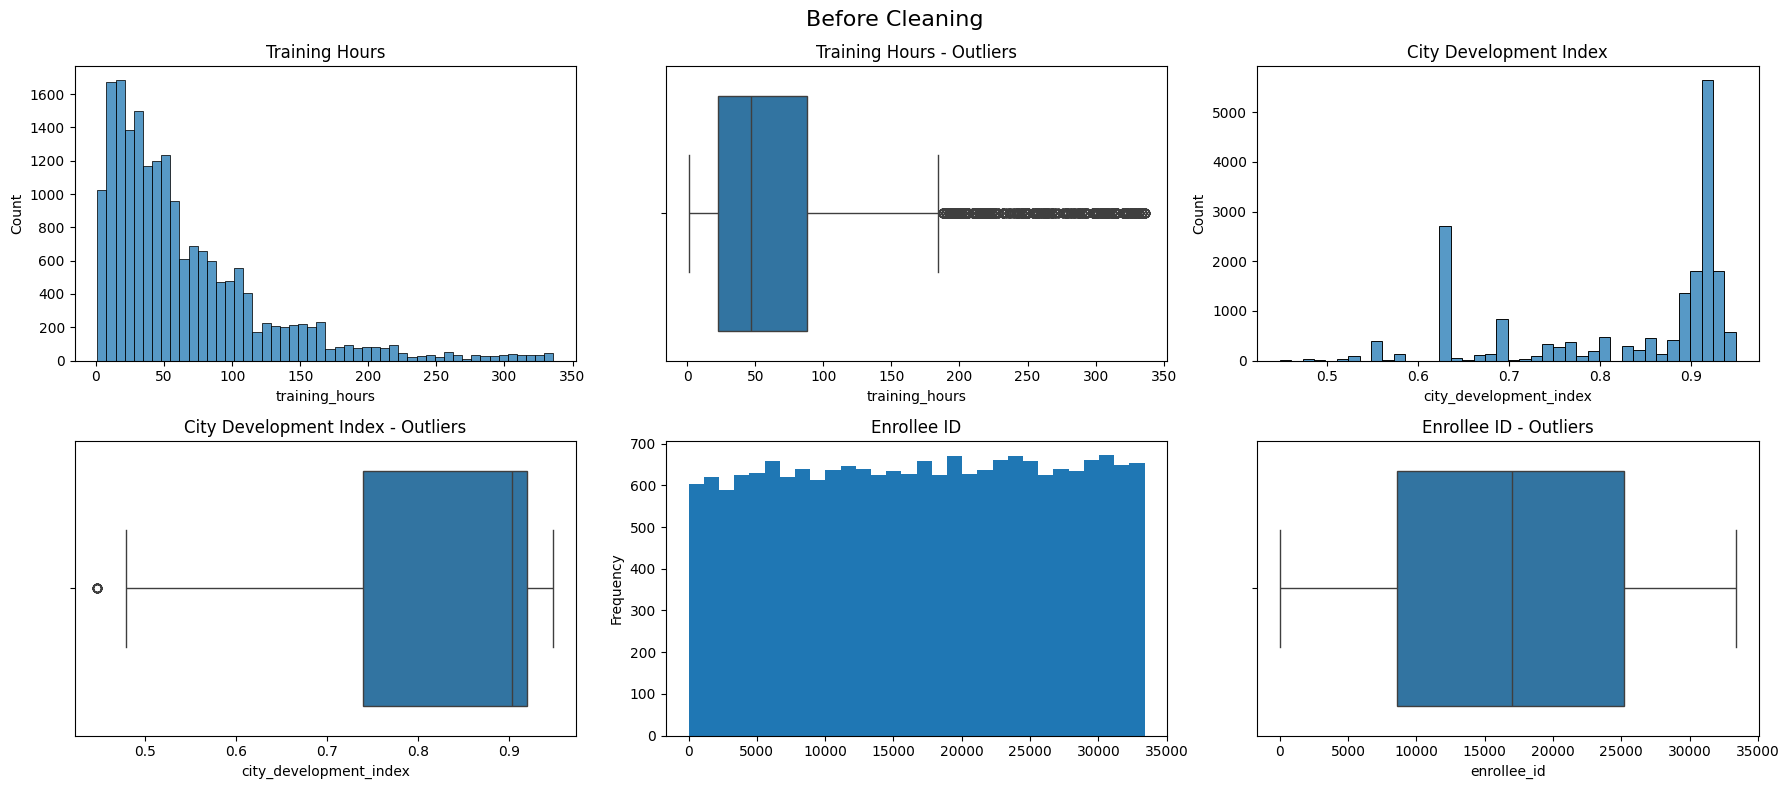

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

sns.histplot(df.training_hours, bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Training Hours")

sns.boxplot(x=df.training_hours, ax=axes[0, 1])
axes[0, 1].set_title("Training Hours - Outliers")

sns.histplot(df.city_development_index, bins=40, ax=axes[0, 2])
axes[0, 2].set_title("City Development Index")

sns.boxplot(x=df.city_development_index, ax=axes[1, 0])
axes[1, 0].set_title("City Development Index - Outliers")

df.enrollee_id.plot(
    kind="hist",
    bins=30,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Enrollee ID")

sns.boxplot(x=df.enrollee_id, ax=axes[1, 2])
axes[1, 2].set_title("Enrollee ID - Outliers")

plt.suptitle("Before Cleaning", fontsize=16)

plt.tight_layout()
plt.show()

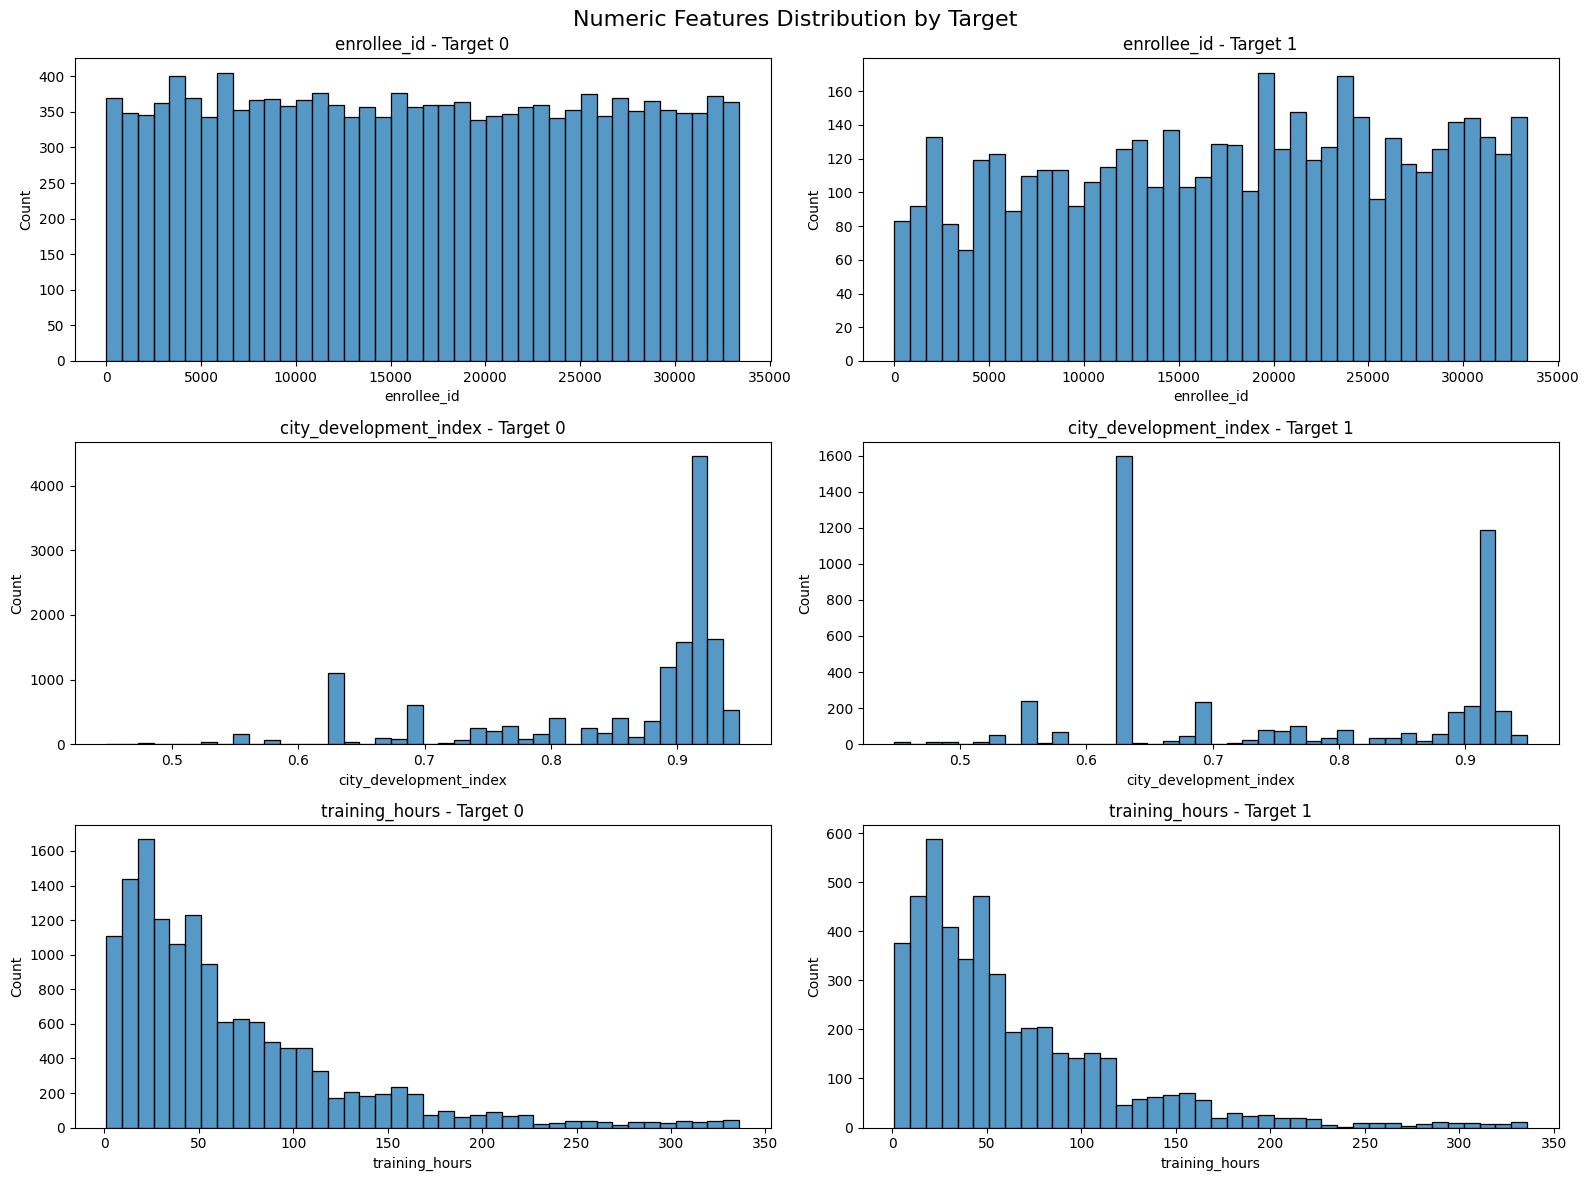

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

cols = [
    'enrollee_id',
    'city_development_index',
    'training_hours'
]

for i, col in enumerate(cols):
    sns.histplot(
        data=df[df['target'] == 0],
        x=col,
        bins=40,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'{col} - Target 0')

    sns.histplot(
        data=df[df['target'] == 1],
        x=col,
        bins=40,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'{col} - Target 1')

plt.suptitle('Numeric Features Distribution by Target', fontsize=16)
plt.tight_layout()
plt.show()

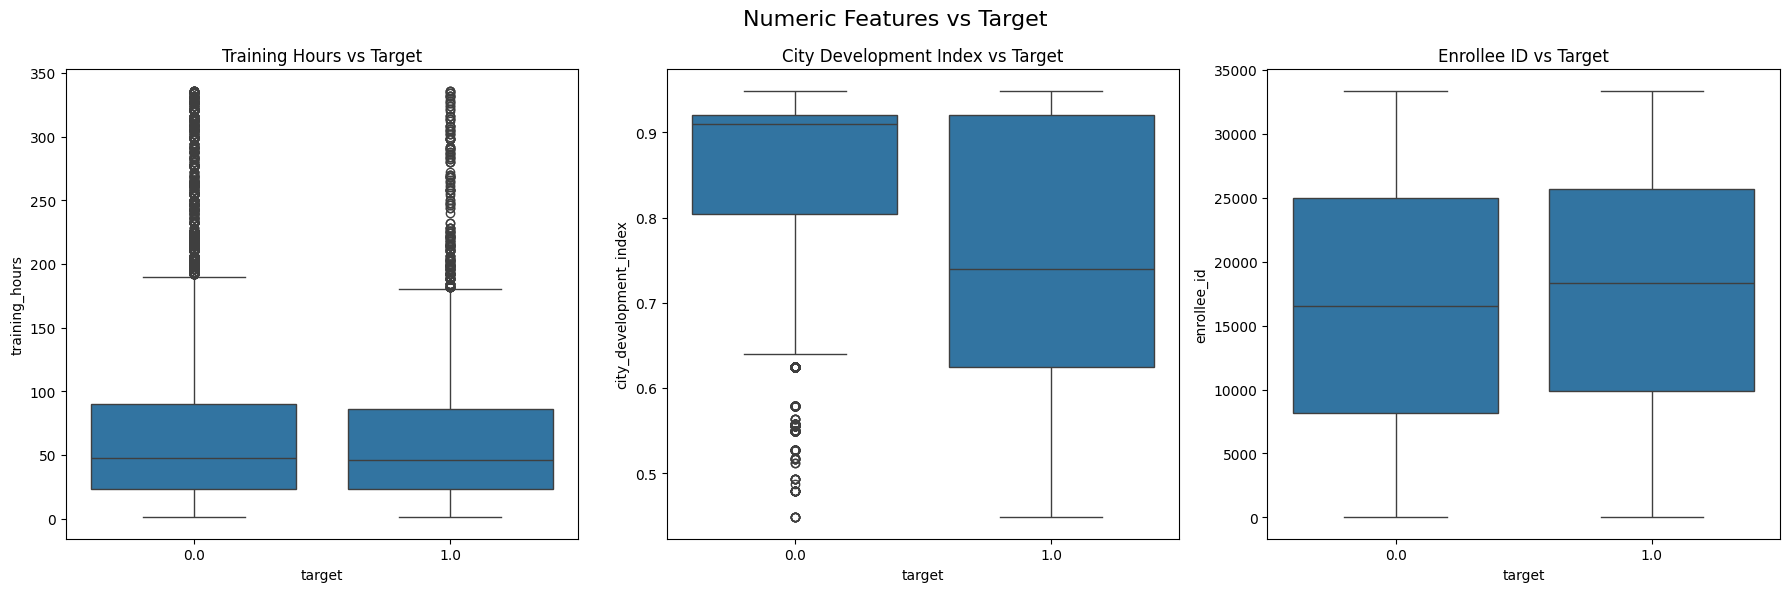

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(
    data=df,
    x='target',
    y='training_hours',
    ax=axes[0]
)
axes[0].set_title('Training Hours vs Target')

sns.boxplot(
    data=df,
    x='target',
    y='city_development_index',
    ax=axes[1]
)
axes[1].set_title('City Development Index vs Target')

sns.boxplot(
    data=df,
    x='target',
    y='enrollee_id',
    ax=axes[2]
)
axes[2].set_title('Enrollee ID vs Target')

plt.suptitle('Numeric Features vs Target', fontsize=16)
plt.tight_layout()
plt.show()

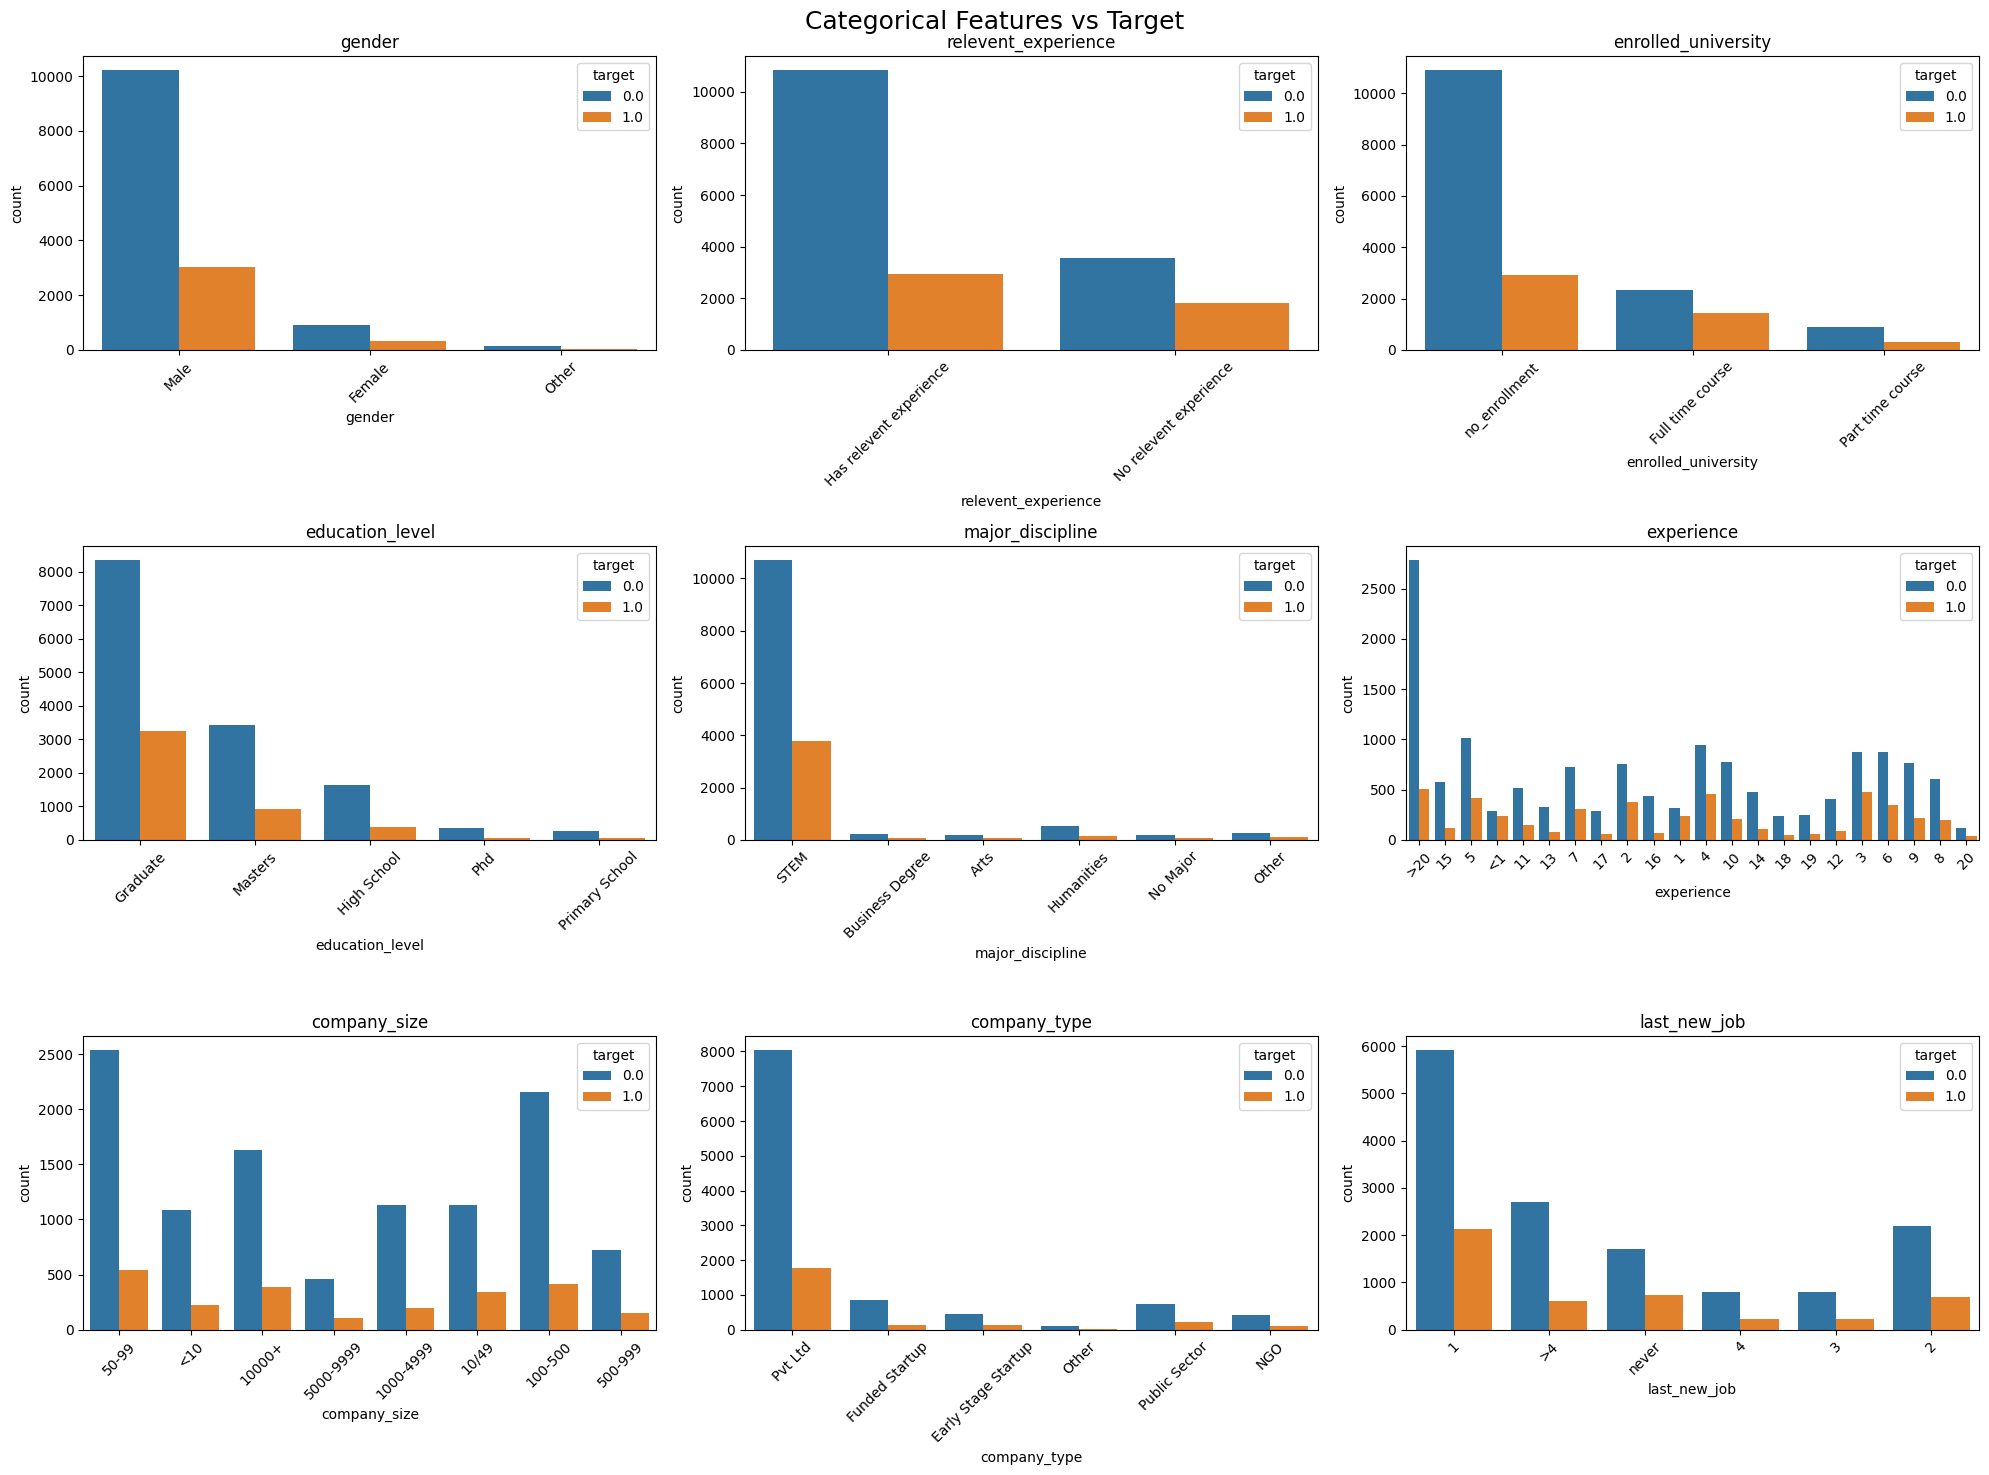

In [14]:
cat_cols = [
    'gender',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'major_discipline',
    'experience',
    'company_size',
    'company_type',
    'last_new_job'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

for ax, col in zip(axes.ravel(), cat_cols):
    sns.countplot(
        data=df,
        x=col,
        hue='target',
        ax=ax
    )

    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features vs Target', fontsize=18)
plt.tight_layout()
plt.show()

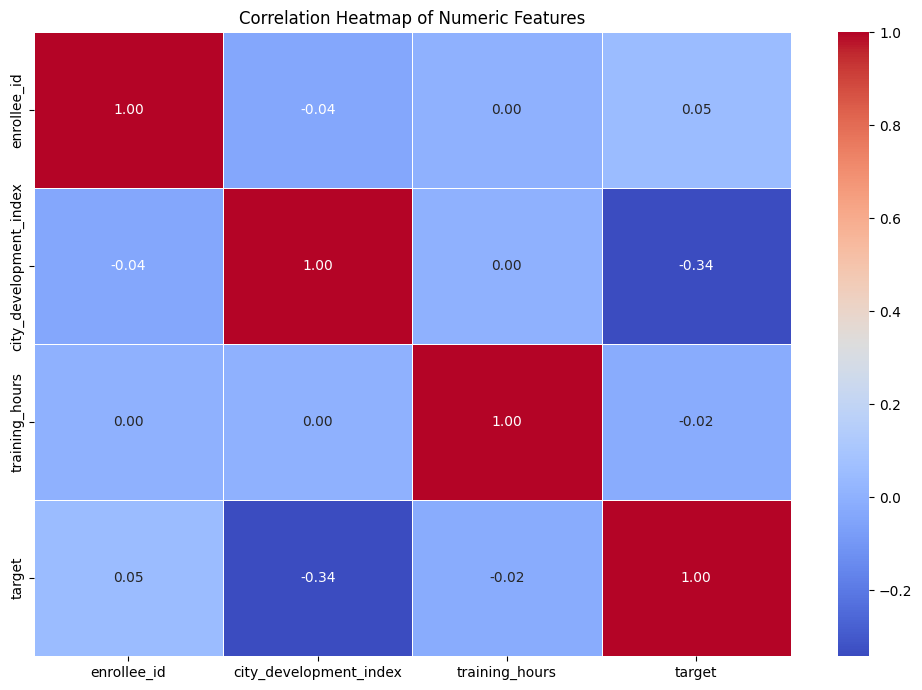

In [15]:
numeric_cols = [
    'enrollee_id',
    'city_development_index',
    'training_hours',
    'target'
]

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

In [16]:
df_clean=df.copy()

Data cleaning

In [17]:
df_clean['gender'] = df_clean['gender'].fillna('Unknown')
df_clean['enrolled_university'] = df_clean['enrolled_university'].fillna(df_clean['enrolled_university'].mode()[0])
df_clean['education_level'] = df_clean['education_level'].fillna(df_clean['education_level'].mode()[0])
df_clean['major_discipline'] = df_clean['major_discipline'].fillna('Unknown')
df_clean['experience'] = df_clean['experience'].replace('>20', '21')
df_clean['experience'] = df_clean['experience'].replace('<1', '0')
df_clean['experience'] = df_clean['experience'].astype(float)
df_clean['experience'] = df_clean['experience'].fillna(df_clean['experience'].median())
df_clean['company_size'] = df_clean['company_size'].fillna('Unknown')
df_clean['company_type'] = df_clean['company_type'].fillna('Unknown')
df_clean['last_new_job'] = df_clean['last_new_job'].fillna(df_clean['last_new_job'].mode()[0])

In [18]:
df_clean.isnull().sum()

,0
enrollee_id,0
city,0
city_development_index,0
gender,0
relevent_experience,0
enrolled_university,0
education_level,0
major_discipline,0
experience,0
company_size,0


In [19]:
df_clean.head()

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,21.0,Unknown,Unknown,1,36,1.0
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15.0,50-99,Pvt Ltd,>4,47,0.0
2,11561,city_21,0.624,Unknown,No relevent experience,Full time course,Graduate,STEM,5.0,Unknown,Unknown,never,83,0.0
3,33241,city_115,0.789,Unknown,No relevent experience,no_enrollment,Graduate,Business Degree,0.0,Unknown,Pvt Ltd,never,52,1.0
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,21.0,50-99,Funded Startup,4,8,0.0


#Visualization after cleaning

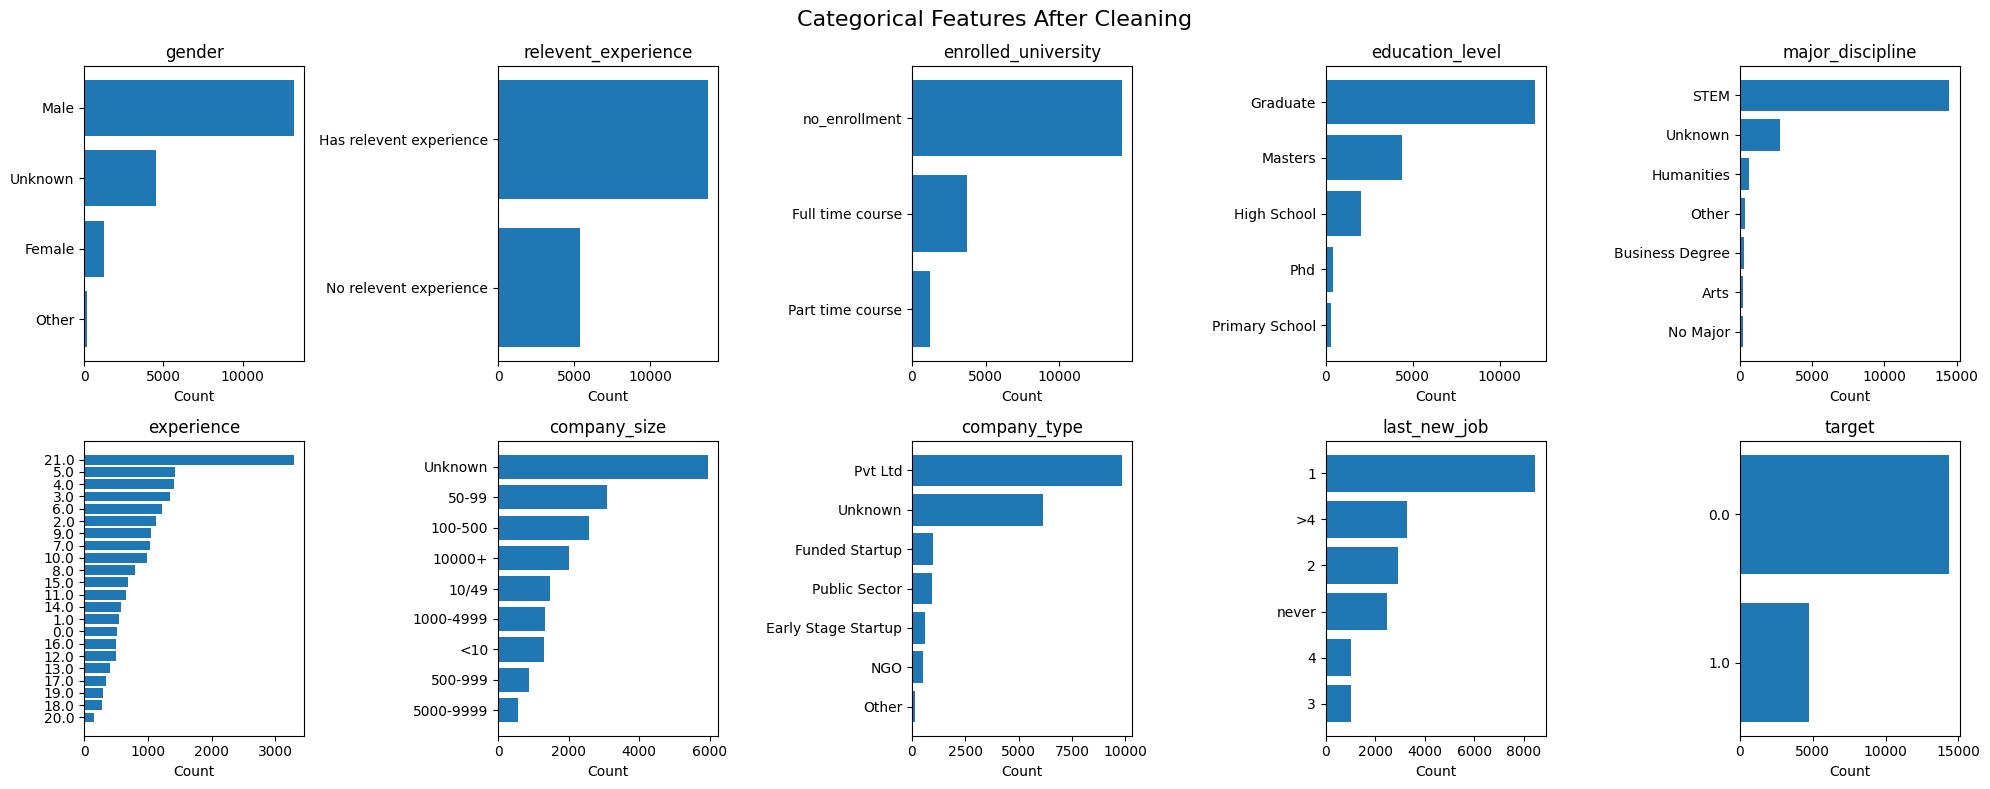

In [20]:
cat_cols = [
    "gender",
    "relevent_experience",
    "enrolled_university",
    "education_level",
    "major_discipline",
    "experience",
    "company_size",
    "company_type",
    "last_new_job",
    "target"
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for ax, col in zip(axes.ravel(), cat_cols):

    counts = df_clean[col].value_counts(dropna=False)

    labels = [
        "MISSING" if pd.isna(x) else str(x)
        for x in counts.index
    ]

    ax.barh(labels[::-1], counts.values[::-1])

    ax.set_title(col)
    ax.set_xlabel("Count")

plt.suptitle("Categorical Features After Cleaning", fontsize=16)

plt.tight_layout()
plt.show()

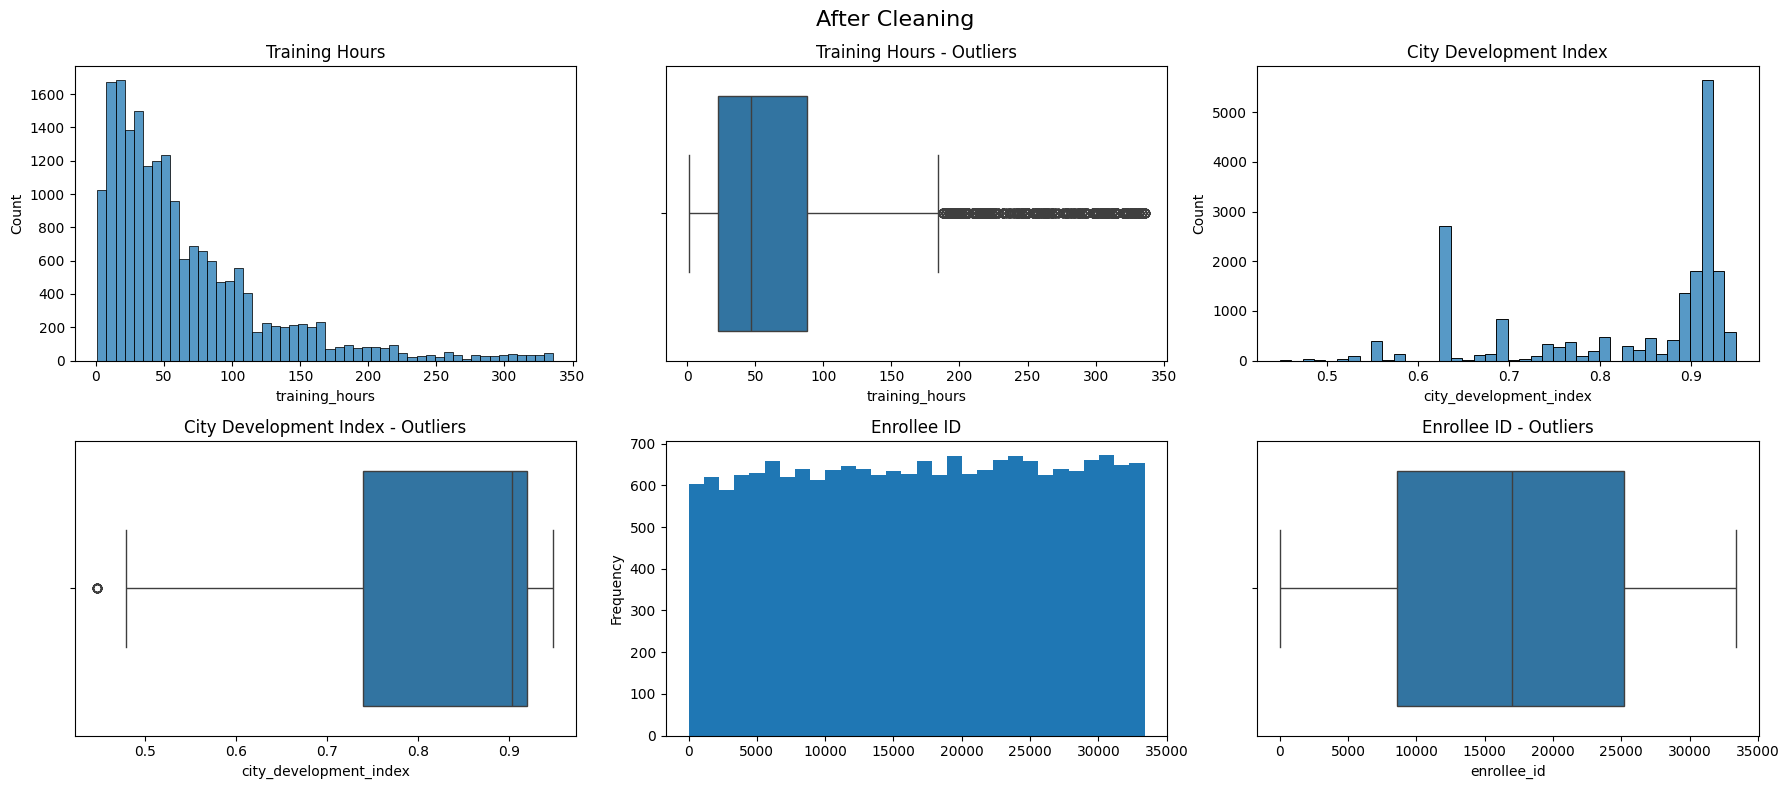

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))

sns.histplot(df_clean.training_hours, bins=50, ax=axes[0, 0])
axes[0, 0].set_title("Training Hours")

sns.boxplot(x=df_clean.training_hours, ax=axes[0, 1])
axes[0, 1].set_title("Training Hours - Outliers")

sns.histplot(df_clean.city_development_index, bins=40, ax=axes[0, 2])
axes[0, 2].set_title("City Development Index")

sns.boxplot(x=df_clean.city_development_index, ax=axes[1, 0])
axes[1, 0].set_title("City Development Index - Outliers")

df_clean.enrollee_id.plot(
    kind="hist",
    bins=30,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Enrollee ID")

sns.boxplot(x=df_clean.enrollee_id, ax=axes[1, 2])
axes[1, 2].set_title("Enrollee ID - Outliers")

plt.suptitle("After Cleaning", fontsize=16)

plt.tight_layout()
plt.show()

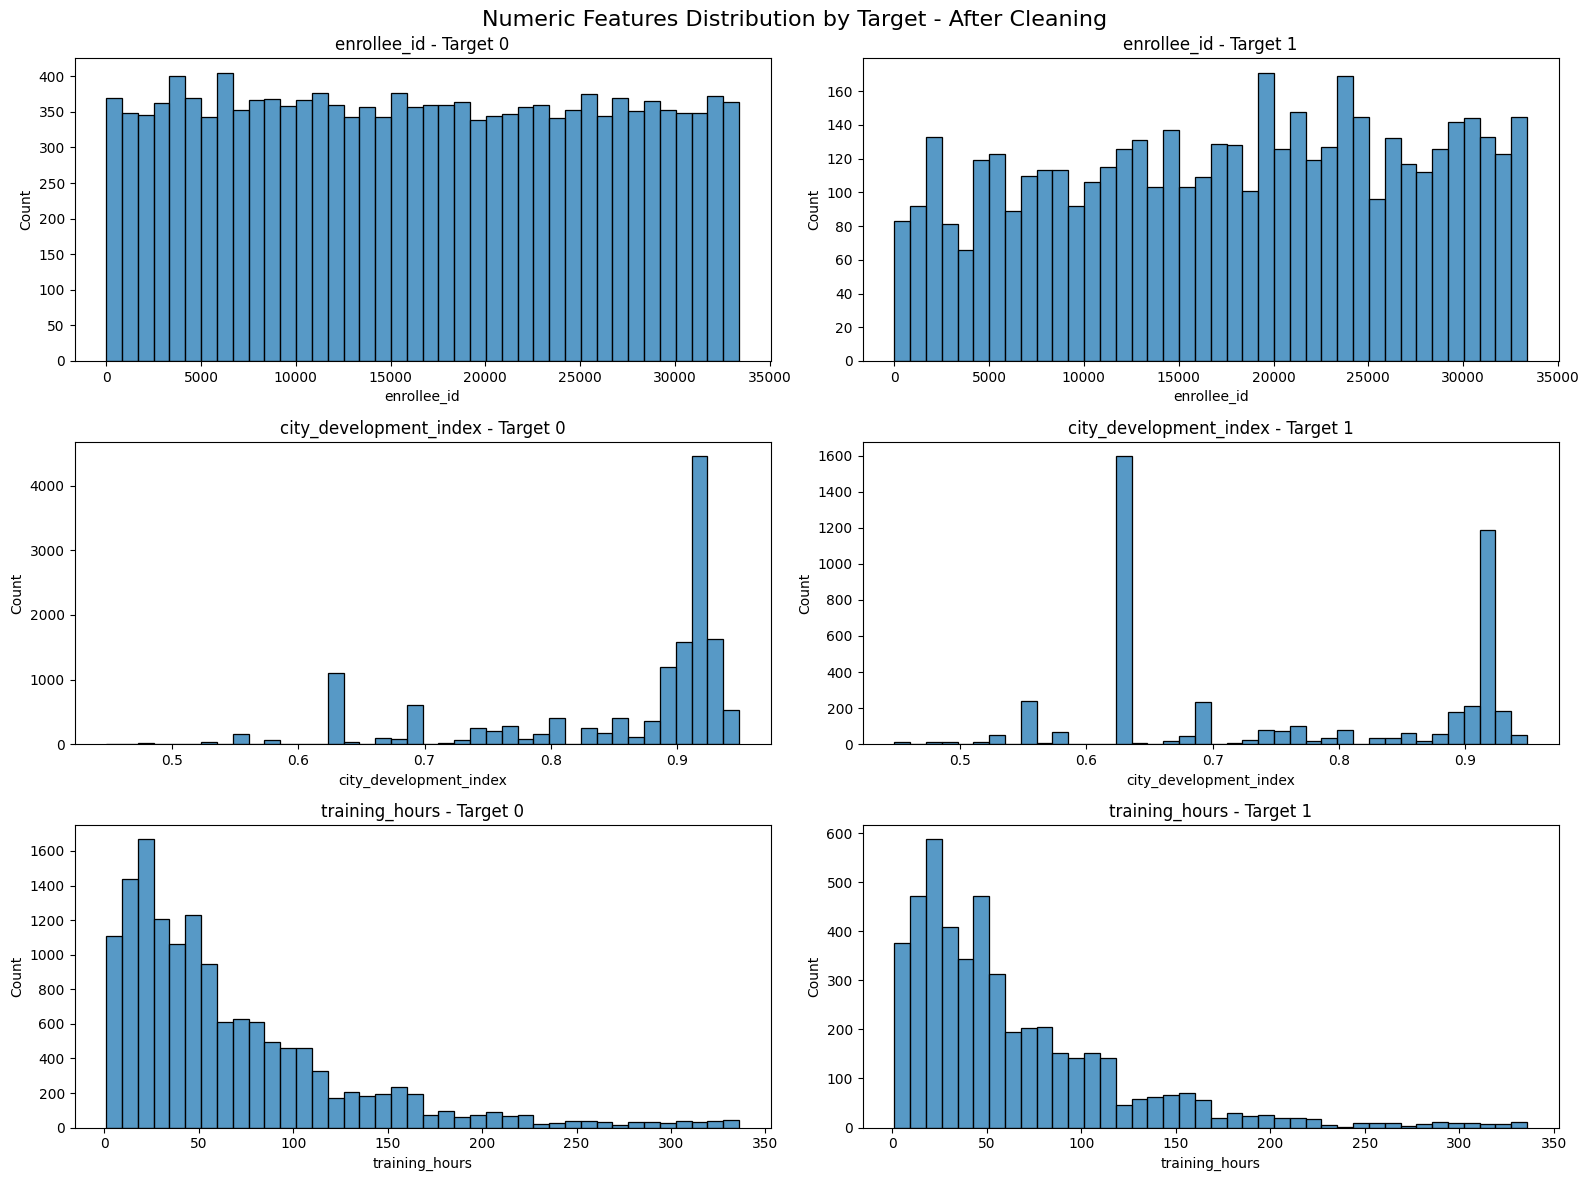

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

cols = [
    'enrollee_id',
    'city_development_index',
    'training_hours'
]

for i, col in enumerate(cols):

    sns.histplot(
        data=df_clean[df_clean['target'] == 0],
        x=col,
        bins=40,
        ax=axes[i, 0]
    )
    axes[i, 0].set_title(f'{col} - Target 0')

    # Target 1
    sns.histplot(
        data=df_clean[df_clean['target'] == 1],
        x=col,
        bins=40,
        ax=axes[i, 1]
    )
    axes[i, 1].set_title(f'{col} - Target 1')

plt.suptitle(
    'Numeric Features Distribution by Target - After Cleaning',
    fontsize=16
)

plt.tight_layout()
plt.show()

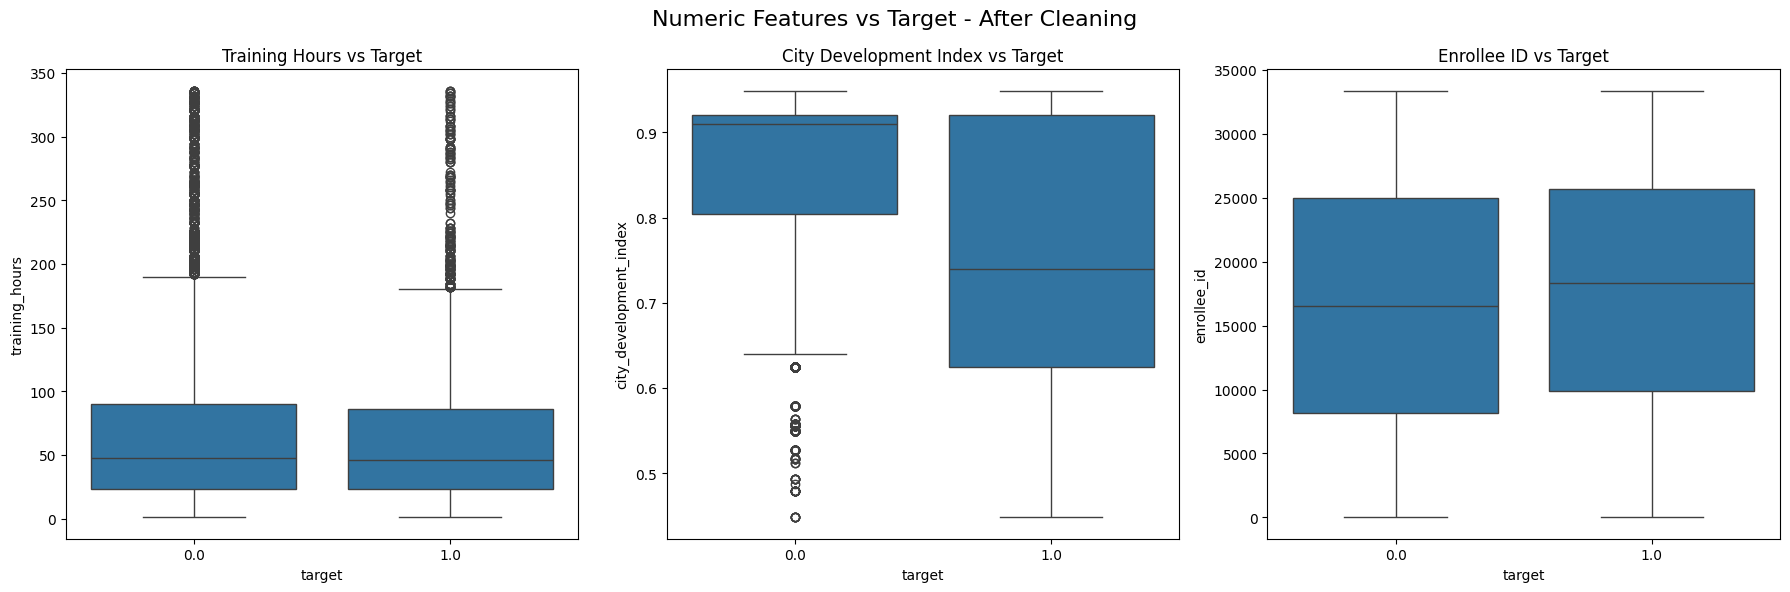

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(
    data=df_clean,
    x='target',
    y='training_hours',
    ax=axes[0]
)

axes[0].set_title('Training Hours vs Target')

sns.boxplot(
    data=df_clean,
    x='target',
    y='city_development_index',
    ax=axes[1]
)

axes[1].set_title('City Development Index vs Target')

sns.boxplot(
    data=df_clean,
    x='target',
    y='enrollee_id',
    ax=axes[2]
)

axes[2].set_title('Enrollee ID vs Target')

plt.suptitle(
    'Numeric Features vs Target - After Cleaning',
    fontsize=16
)

plt.tight_layout()
plt.show()

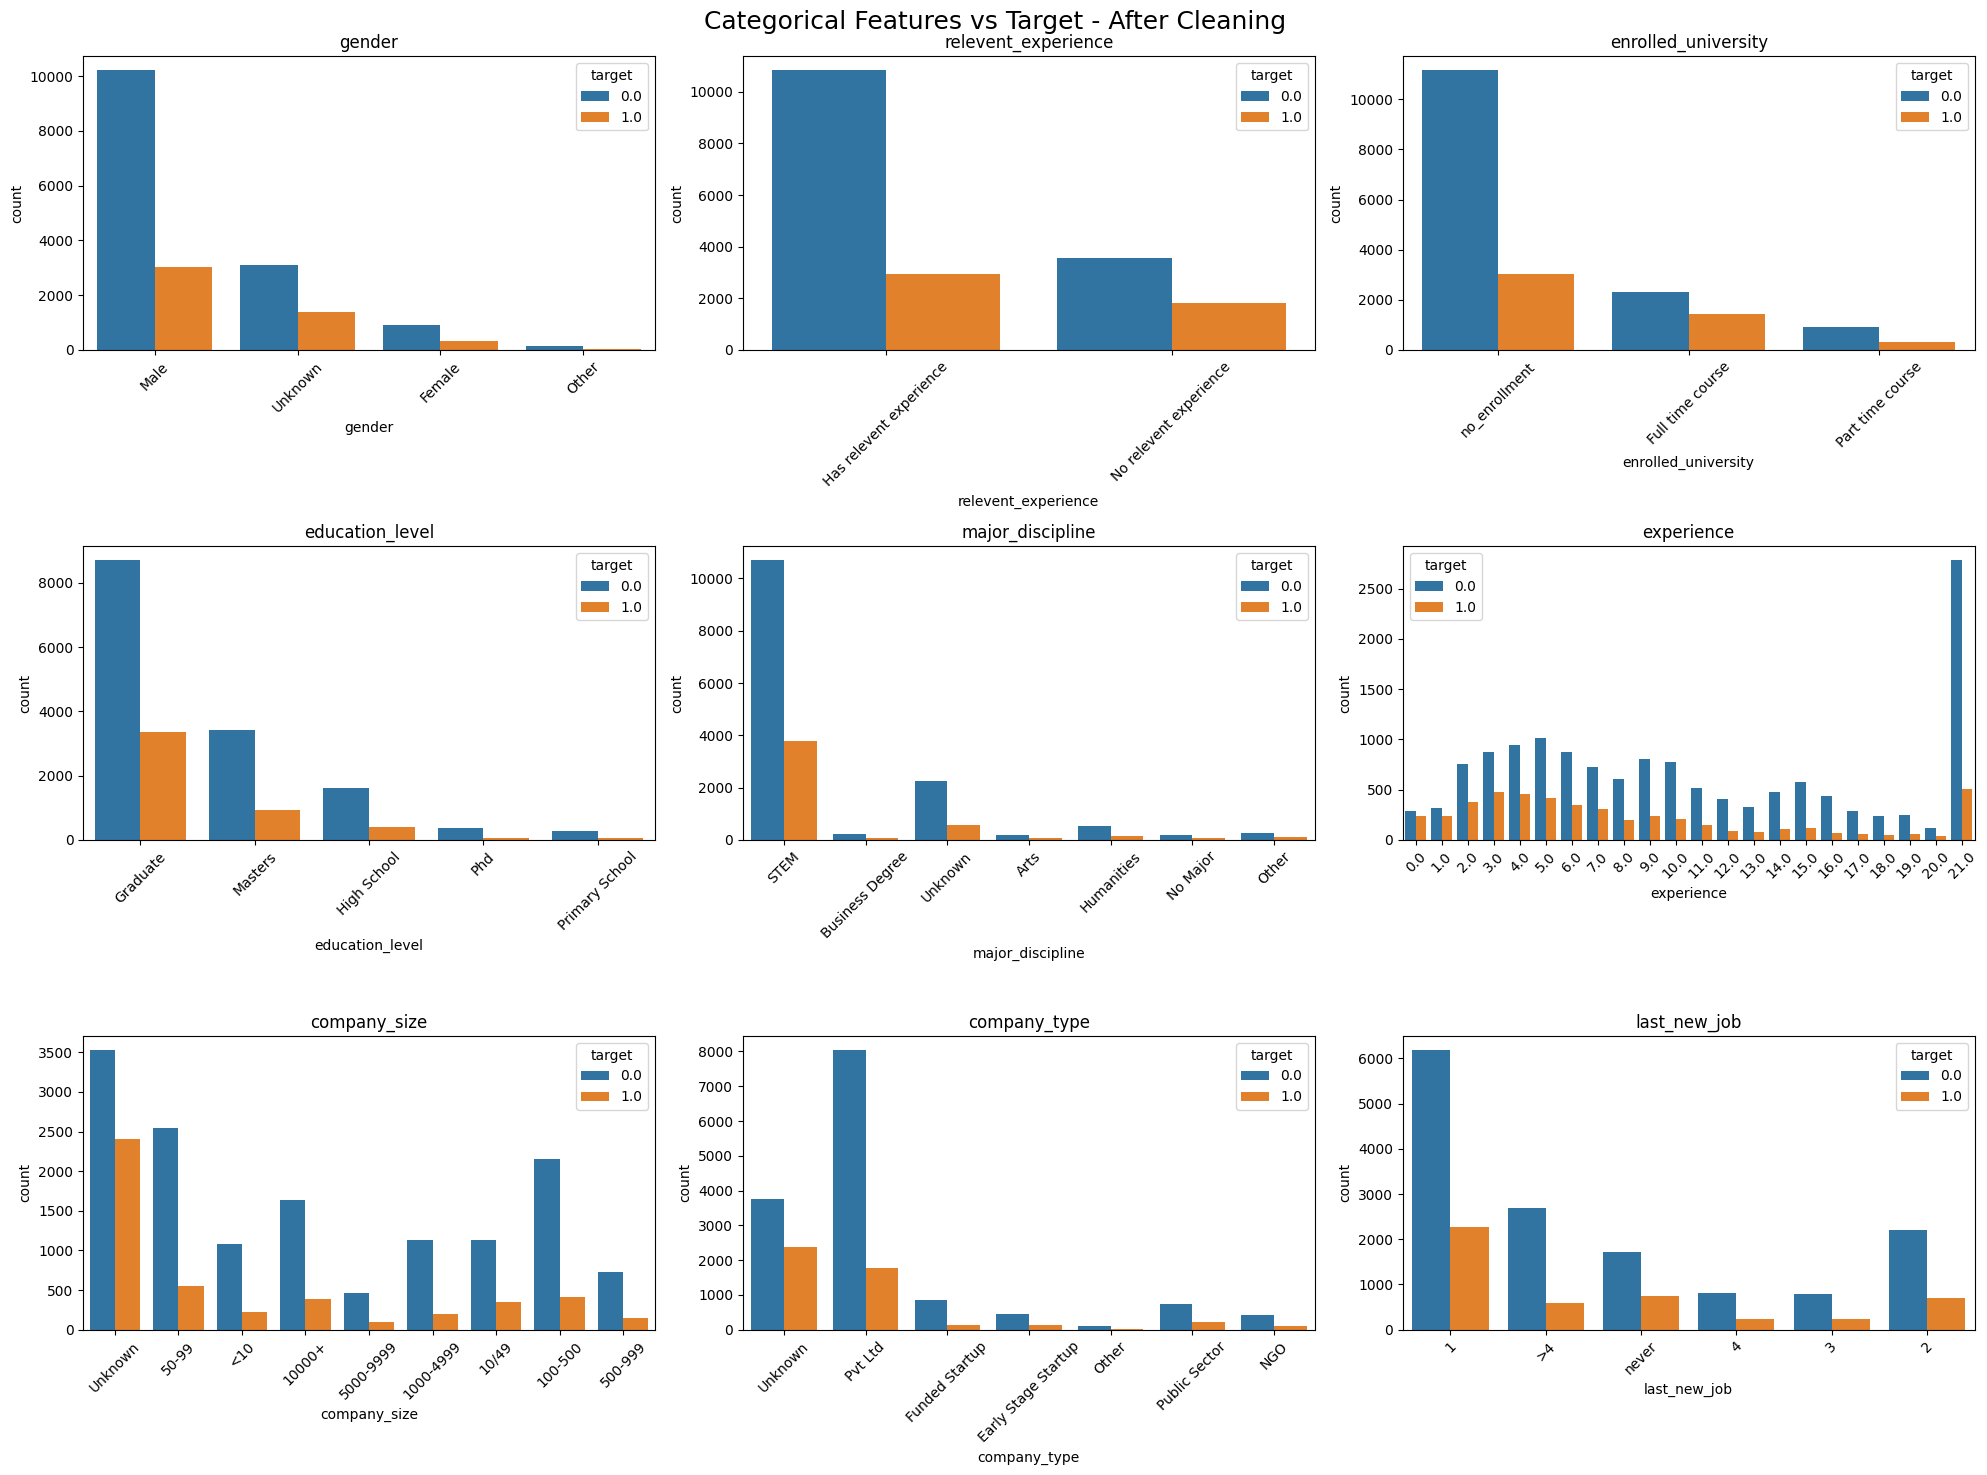

In [24]:
cat_cols = [
    'gender',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'major_discipline',
    'experience',
    'company_size',
    'company_type',
    'last_new_job'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 15))

for ax, col in zip(axes.ravel(), cat_cols):

    sns.countplot(
        data=df_clean,
        x=col,
        hue='target',
        ax=ax
    )

    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle(
    'Categorical Features vs Target - After Cleaning',
    fontsize=18
)

plt.tight_layout()
plt.show()

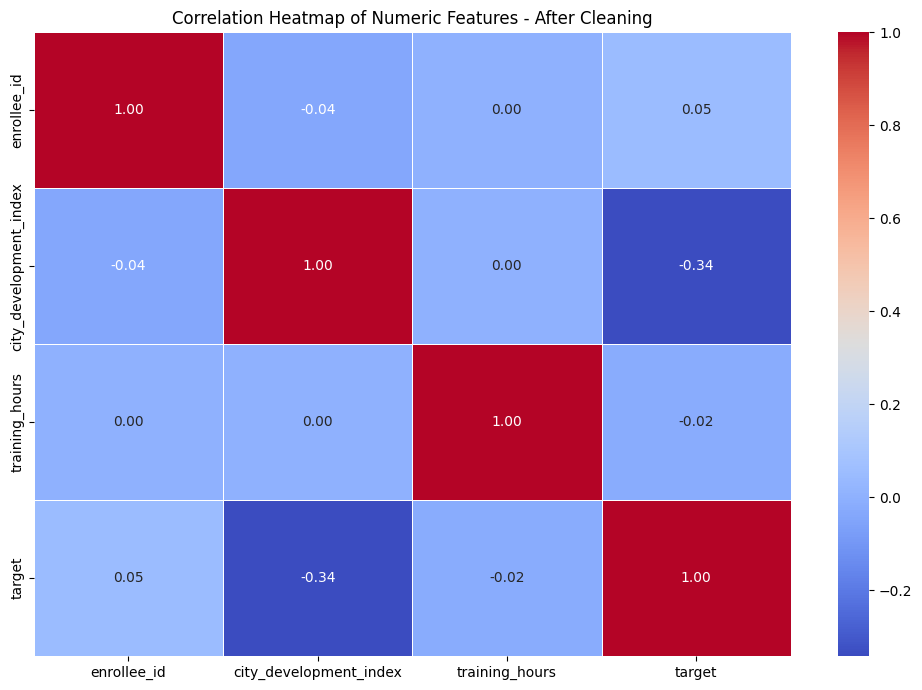

In [25]:
numeric_cols = [
    'enrollee_id',
    'city_development_index',
    'training_hours',
    'target'
]

corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numeric Features - After Cleaning')
plt.tight_layout()
plt.show()

In [26]:
x=df_clean.drop(columns=['target','enrollee_id'])
y=df_clean['target']

Train Test split

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)

Encoding

In [28]:
encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
categorical_cols = [
    'city',
    'gender',
    'relevent_experience',
    'enrolled_university',
    'education_level',
    'major_discipline',
    'company_size',
    'company_type',
    'last_new_job',
]

In [29]:
X_train_cat=encoder.fit_transform(X_train[categorical_cols])
X_test_cat=encoder.transform(X_test[categorical_cols])

In [30]:
numeric_cols = [
    'city_development_index',
    'training_hours',
    'experience'
]

Scaling

In [31]:
scaler=StandardScaler()
X_train_num=scaler.fit_transform(X_train[numeric_cols])
X_test_num=scaler.transform(X_test[numeric_cols])

In [32]:
X_train_encoded = np.concatenate([X_train_cat, X_train_num], axis=1)
X_test_encoded = np.concatenate([X_test_cat, X_test_num], axis=1)

all_names = categorical_cols + numeric_cols

X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=all_names,
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=all_names,
    index=X_test.index
)

In [33]:
X_train_encoded.head()

,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,company_size,company_type,last_new_job,city_development_index,training_hours,experience
13330,47.0,3.0,1.0,2.0,1.0,6.0,8.0,6.0,5.0,0.657186,-0.822220,-1.202474
18074,30.0,1.0,0.0,2.0,2.0,5.0,2.0,5.0,0.0,0.551630,3.277426,-0.610088
366,47.0,1.0,1.0,2.0,0.0,6.0,8.0,6.0,5.0,0.657186,-0.688898,-1.054378
10662,47.0,1.0,1.0,2.0,1.0,6.0,8.0,6.0,0.0,0.657186,-0.505581,-1.054378
13974,38.0,1.0,0.0,0.0,0.0,5.0,8.0,6.0,0.0,-2.225316,-0.372259,-0.906281


feature importances

DecisionTree

In [34]:
dt = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced')
dt.fit(X_train_encoded, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, random_state=42)

In [35]:
y_train_pred_dt = dt.predict(X_train_encoded)
print("\nTrain Classification Report:\n", classification_report(y_train, y_train_pred_dt))


Train Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.80      0.85     11501
         1.0       0.55      0.74      0.63      3825

    accuracy                           0.79     15326
   macro avg       0.73      0.77      0.74     15326
weighted avg       0.81      0.79      0.79     15326



In [36]:
y_pred_dt = dt.predict(X_test_encoded)

In [37]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nTest Classification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Accuracy: 0.778705636743215

Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.80      0.84      2880
         1.0       0.54      0.72      0.62       952

    accuracy                           0.78      3832
   macro avg       0.72      0.76      0.73      3832
weighted avg       0.81      0.78      0.79      3832


Confusion Matrix:
 [[2302  578]
 [ 270  682]]


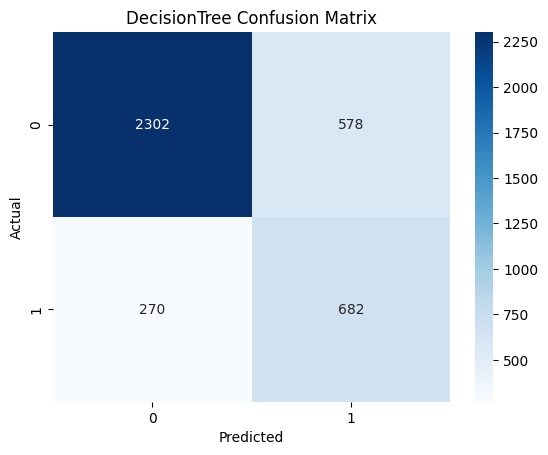

In [38]:
sns.heatmap(confusion_matrix(y_test, y_pred_dt),annot=True ,fmt='d',cmap='Blues')
plt.title('DecisionTree Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

RandomForest

In [39]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_encoded, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [40]:
y_train_pred_rf = rf.predict(X_train_encoded)
print("\nTrain Classification Report:\n", classification_report(y_train, y_train_pred_rf))


Train Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.82      0.87     11501
         1.0       0.59      0.76      0.66      3825

    accuracy                           0.81     15326
   macro avg       0.75      0.79      0.76     15326
weighted avg       0.83      0.81      0.82     15326



In [41]:
y_pred_rf = rf.predict(X_test_encoded)

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nTest Classification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.7894050104384134

Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.81      0.85      2880
         1.0       0.56      0.72      0.63       952

    accuracy                           0.79      3832
   macro avg       0.73      0.77      0.74      3832
weighted avg       0.81      0.79      0.80      3832


Confusion Matrix:
 [[2338  542]
 [ 265  687]]


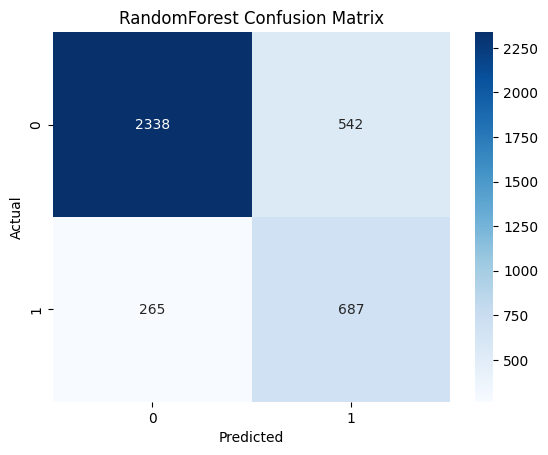

In [43]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf),annot=True ,fmt='d',cmap='Blues')
plt.title('RandomForest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [44]:
importances = pd.Series(rf.feature_importances_, index=X_train_encoded.columns)
importances.sort_values(ascending=False).head(15)

,0
city_development_index,0.341760
company_size,0.141628
city,0.122604
company_type,0.093465
experience,0.073463
training_hours,0.059808
major_discipline,0.042870
last_new_job,0.032660
education_level,0.028550
enrolled_university,0.027021


LogisticRegression

In [45]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_encoded, y_train)

LogisticRegression(max_iter=1000)

In [46]:
y_train_pred_lr = lr.predict(X_train_encoded)
print("\nTrain Classification Report:\n", classification_report(y_train, y_train_pred_lr))


Train Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.93      0.86     11501
         1.0       0.58      0.27      0.37      3825

    accuracy                           0.77     15326
   macro avg       0.69      0.60      0.61     15326
weighted avg       0.74      0.77      0.74     15326



In [47]:
y_pred_lr=lr.predict(X_test_encoded)

In [48]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nTest Classification Report:\n", classification_report(y_test, y_pred_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

Accuracy: 0.7724425887265136

Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.80      0.93      0.86      2880
         1.0       0.58      0.29      0.39       952

    accuracy                           0.77      3832
   macro avg       0.69      0.61      0.62      3832
weighted avg       0.75      0.77      0.74      3832


Confusion Matrix:
 [[2684  196]
 [ 676  276]]


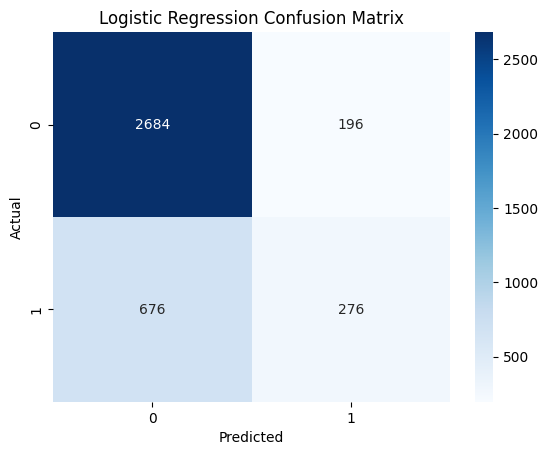

In [49]:
sns.heatmap(confusion_matrix(y_test, y_pred_lr),annot=True ,fmt='d',cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

SVM


In [ ]:
F_X_train_encoded = X_train_encoded.copy()
sc2 = StandardScaler()
F_X_train_encoded = sc2.fit_transform(F_X_train_encoded)
F_X_test_encoded = X_test_encoded.copy()
F_X_test_encoded  = sc2.transform(F_X_test_encoded)

In [ ]:
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    random_state=42,
    class_weight='balanced',
    probability=True
)

svm.fit(F_X_train_encoded, y_train)

SVC(C=10, probability=True, random_state=42)

In [ ]:
y_train_pred_svm = svm.predict(F_X_train_encoded)
print("\nTrain Classification Report:\n", classification_report(y_train, y_train_pred_svm))


Train Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.91      0.86     11501
         1.0       0.58      0.36      0.45      3825

    accuracy                           0.77     15326
   macro avg       0.69      0.64      0.65     15326
weighted avg       0.75      0.77      0.76     15326



In [ ]:
y_pred_svm = svm.predict(F_X_test_encoded)

In [ ]:

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nTest Classification Report:\n", classification_report(y_test, y_pred_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

Accuracy: 0.7682672233820459

Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.81      0.90      0.85      2880
         1.0       0.55      0.37      0.44       952

    accuracy                           0.77      3832
   macro avg       0.68      0.63      0.65      3832
weighted avg       0.75      0.77      0.75      3832


Confusion Matrix:
 [[2592  288]
 [ 600  352]]


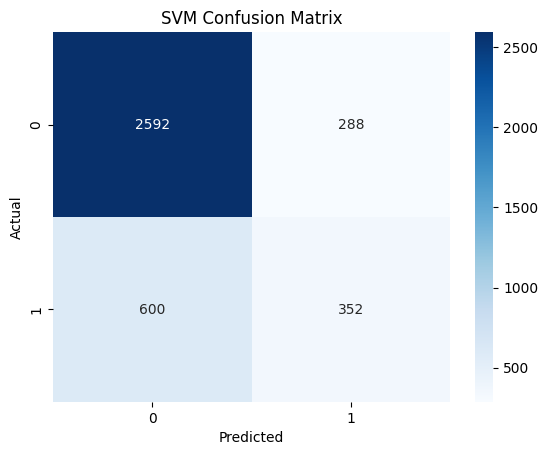

In [54]:
sns.heatmap(confusion_matrix(y_test, y_pred_svm),annot=True ,fmt='d',cmap='Blues')
plt.title('SVM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

**XGboost**

In [55]:
scale_weight = (y_train == 0).sum() / (y_train == 1).sum()

In [56]:
xgb= XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_weight,
    reg_alpha=1,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_encoded, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [57]:
y_train_pred_xgb = xgb.predict(X_train_encoded)
print("\nTrain Classification Report:\n", classification_report(y_train, y_train_pred_xgb))


Train Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.79      0.85     11501
         1.0       0.55      0.76      0.64      3825

    accuracy                           0.78     15326
   macro avg       0.73      0.78      0.74     15326
weighted avg       0.82      0.78      0.79     15326



In [58]:
y_pred_xgb=xgb.predict(X_test_encoded)

In [59]:
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nTest Classification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Accuracy: 0.782098121085595

Test Classification Report:
               precision    recall  f1-score   support

         0.0       0.91      0.79      0.85      2880
         1.0       0.54      0.75      0.63       952

    accuracy                           0.78      3832
   macro avg       0.73      0.77      0.74      3832
weighted avg       0.82      0.78      0.79      3832


Confusion Matrix:
 [[2283  597]
 [ 238  714]]


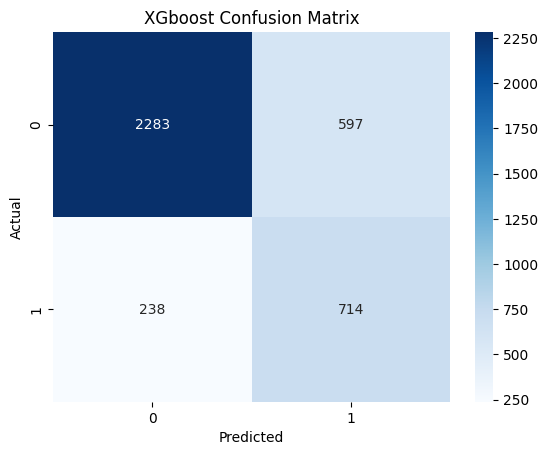

In [60]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb),annot=True ,fmt='d',cmap='Blues')
plt.title('XGboost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

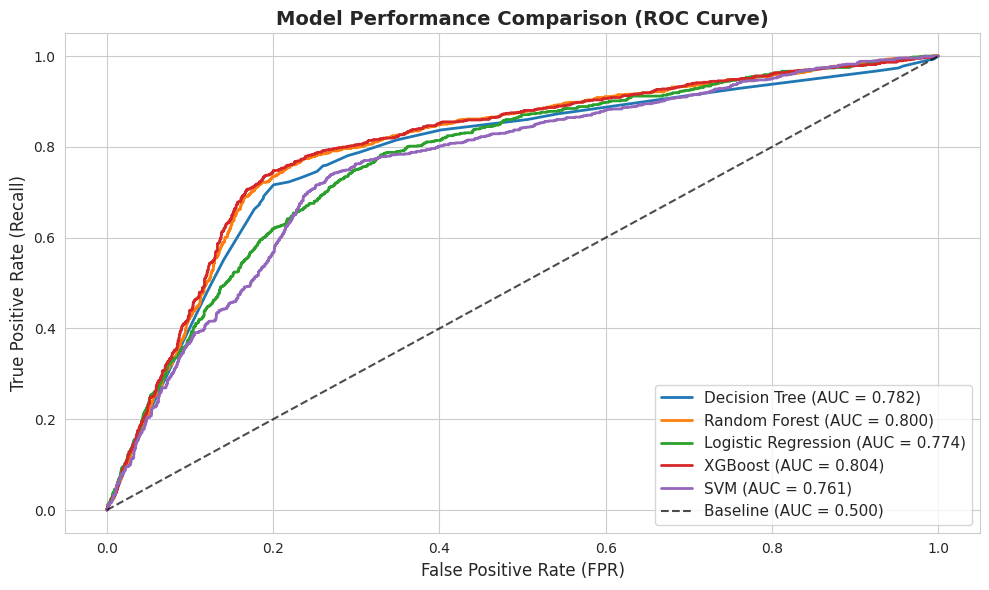

In [ ]:

trained_models = {
    'Decision Tree':       (dt,   X_test_encoded),
    'Random Forest':       (rf,   X_test_encoded),
    'Logistic Regression': (lr,   X_test_encoded),
    'XGBoost':             (xgb,  X_test_encoded),
    'SVM':                 (svm, F_X_test_encoded),
}

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

for name, (model, X_te) in trained_models.items():
    if hasattr(model, "predict_proba"):
        scores = model.predict_proba(X_te)[:, 1]
    else:
        scores = model.decision_function(X_te)

    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_score = roc_auc_score(y_test, scores)

    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Baseline (AUC = 0.500)', alpha=0.7)
plt.title('Model Performance Comparison (ROC Curve)', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

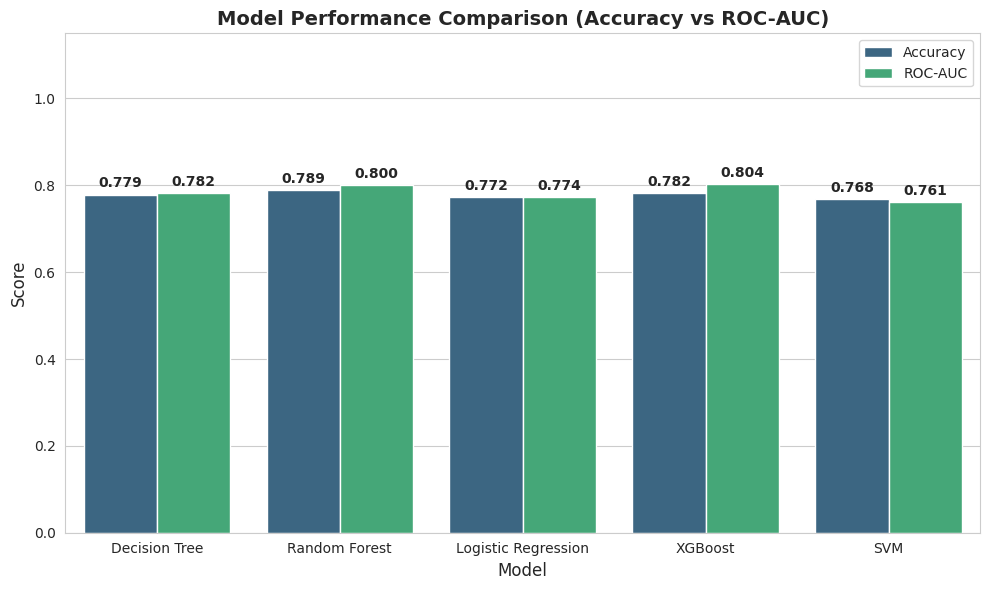

In [ ]:
trained_models = {
    'Decision Tree':       (dt,   X_test_encoded),
    'Random Forest':       (rf,   X_test_encoded),
    'Logistic Regression': (lr,   X_test_encoded),
    'XGBoost':             (xgb,  X_test_encoded),
    'SVM':                 (svm, F_X_test_encoded),
}

metrics_list = []
for name, (model, X_te) in trained_models.items():
    preds = model.predict(X_te)
    scores = (model.predict_proba(X_te)[:, 1] if hasattr(model, "predict_proba")
              else model.decision_function(X_te))

    metrics_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'ROC-AUC': roc_auc_score(y_test, scores)
    })

df_metrics = pd.DataFrame(metrics_list)
df_melted = df_metrics.melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 6))
sns.set_style('whitegrid')

ax = sns.barplot(
    data=df_melted, x='Model', y='Score', hue='Metric', palette='viridis'
)

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(
            f'{height:.3f}',
            (p.get_x() + p.get_width() / 2.0, height),
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold',
            xytext=(0, 3),
            textcoords='offset points',
        )

plt.title(
    'Model Performance Comparison (Accuracy vs ROC-AUC)',
    fontsize=14,
    fontweight='bold',
)
plt.ylim(0, 1.15)
plt.ylabel('Score', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.legend(loc='upper right')
plt.tight_layout()

plt.show()

In [63]:
import os
import joblib
os.makedirs('models', exist_ok=True)

joblib.dump(xgb, 'models/xgb_model.pkl')

joblib.dump(encoder, 'models/encoder.pkl')

joblib.dump(scaler, 'models/scaler.pkl')

print("All models and transformers have been saved successfully in 'models/' directory!")

All models and transformers have been saved successfully in 'models/' directory!
